--- Statistical Analysis ---
Expected Mean for 0-255 is ~127.5

Pseudo-Random -> Mean: 125.14, Variance: 5471.26
Quantum-Random -> Mean: 128.57, Variance: 5339.08


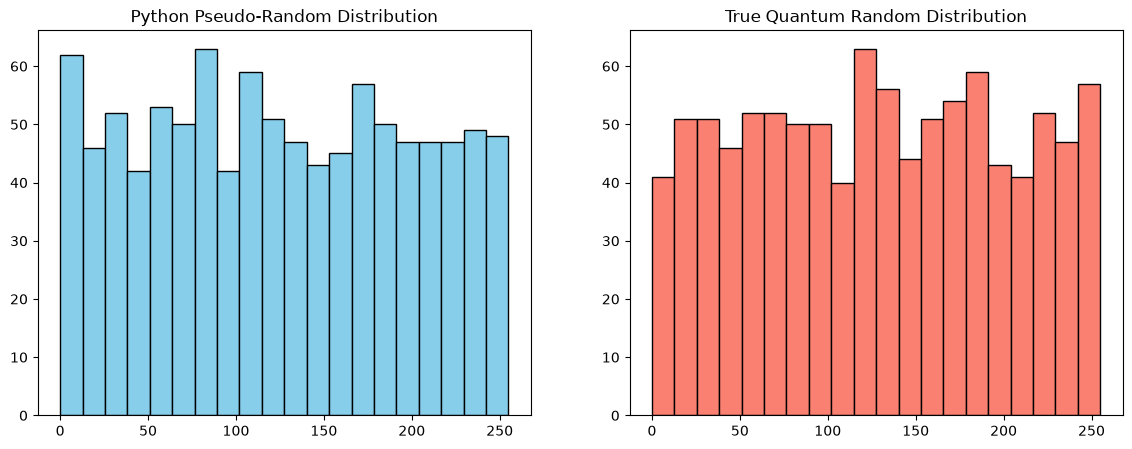

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

num_samples = 1000

# --- 1. Python's Pseudo-Random Generator ---
pseudo_random_nums = [random.randint(0, 255) for _ in range(num_samples)]

# --- 2. Quantum Random Number Generator ---
# 8 qubits give us 8 classical bits (0 to 255)
qc_qrng = QuantumCircuit(8, 8)
qc_qrng.h(range(8))
qc_qrng.measure(range(8), range(8))

simulator = AerSimulator()
compiled_qrng = transpile(qc_qrng, simulator)

# Setting memory=True allows us to retrieve individual shot results!
job = simulator.run(compiled_qrng, shots=num_samples, memory=True)
bitstrings = job.result().get_memory()

# Convert binary string outputs (e.g., '11001010') to integers
quantum_random_nums = [int(bits, 2) for bits in bitstrings]

# --- 3. Statistical Comparison ---
print("--- Statistical Analysis ---")
print(f"Expected Mean for 0-255 is ~127.5\n")
print(f"Pseudo-Random -> Mean: {np.mean(pseudo_random_nums):.2f}, Variance: {np.var(pseudo_random_nums):.2f}")
print(f"Quantum-Random -> Mean: {np.mean(quantum_random_nums):.2f}, Variance: {np.var(quantum_random_nums):.2f}")

# --- 4. Plotting the Distributions ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(pseudo_random_nums, bins=20, color='skyblue', edgecolor='black')
ax[0].set_title('Python Pseudo-Random Distribution')

ax[1].hist(quantum_random_nums, bins=20, color='salmon', edgecolor='black')
ax[1].set_title('True Quantum Random Distribution')

plt.show()